In [4]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv("ford.csv")



In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [6]:
df.shape

(17966, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [8]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


`df.describe()` provides a statistical summary of the numeric columns in the dataset: `year`, `price`, `mileage`, `tax`, `mpg`, and `engineSize`.

### Analysis
- **count** shows that all numeric columns have the same number of non-null values, so there are no missing values in these fields.
- **mean** gives the average value for each numeric feature.
- **std** shows the spread of the data; a larger standard deviation means the values are more dispersed.
- **min** and **max** indicate the range of each column.
- **25%**, **50%** (median), and **75%** show the distribution of values and help identify skewness.

### Key observations
- `price` and `mileage` usually have the widest range, suggesting high variability in car values and usage.
- `year` is expected to be concentrated in a recent range, since the dataset contains used cars.
- `engineSize`, `tax`, and `mpg` help describe vehicle characteristics and may influence price.
- If the mean is far from the median, the column may be skewed.


# EDA


<Axes: xlabel='price', ylabel='Count'>

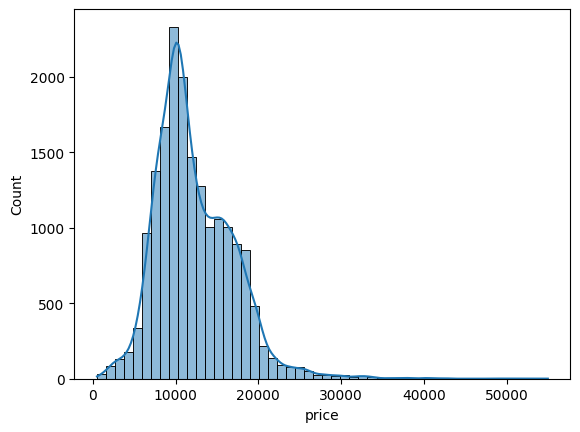

In [9]:
sns.histplot(df['price'],bins = 50,kde = True)

<Axes: >

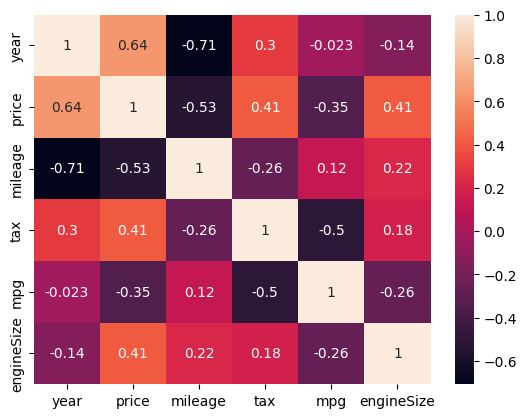

In [10]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

### Heatmap insights

- Price vs Year: strong positive correlation — newer cars tend to have higher prices.  
- Price vs Mileage: strong negative correlation — higher mileage → lower price.  
- EngineSize vs Tax: strong positive correlation — larger engines incur higher tax.  
- EngineSize vs MPG: strong negative correlation — larger engines have lower mpg.  
- MPG vs Price: negative correlation (higher mpg often associated with lower-priced, smaller-engine cars).  
- Year vs Mileage: negative correlation — newer cars typically have lower mileage.  
- Implication: year, mileage, engineSize, tax, and mpg are the most informative features for predicting price.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

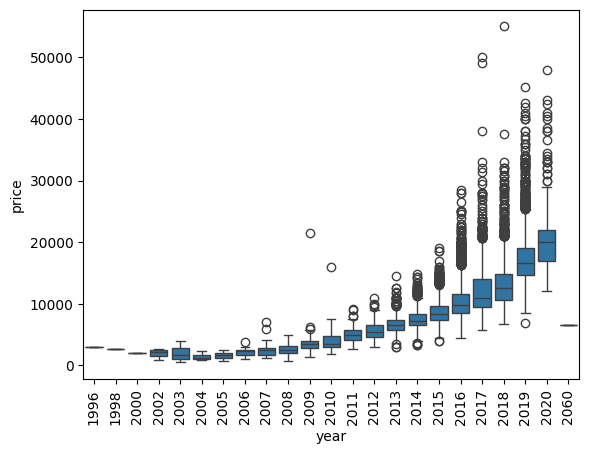

In [11]:
sns.boxplot(data = df, x = 'year', y = 'price')
plt.xticks(rotation = 90)

In [12]:
df = df[df['year'] != 2060].reset_index(drop=True)

<Axes: xlabel='mileage', ylabel='price'>

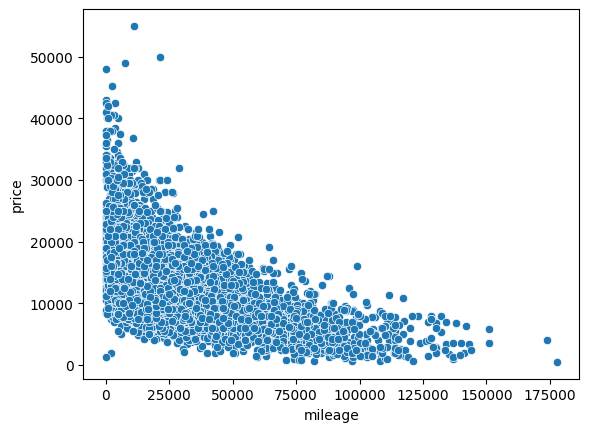

In [13]:
sns.scatterplot(data = df, x = 'mileage',y = 'price')

<Axes: xlabel='engineSize', ylabel='price'>

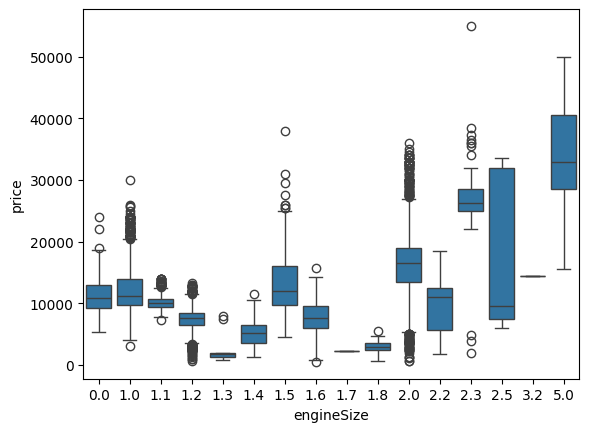

In [14]:
sns.boxplot(data = df, x = 'engineSize', y = 'price')

<Axes: xlabel='transmission', ylabel='price'>

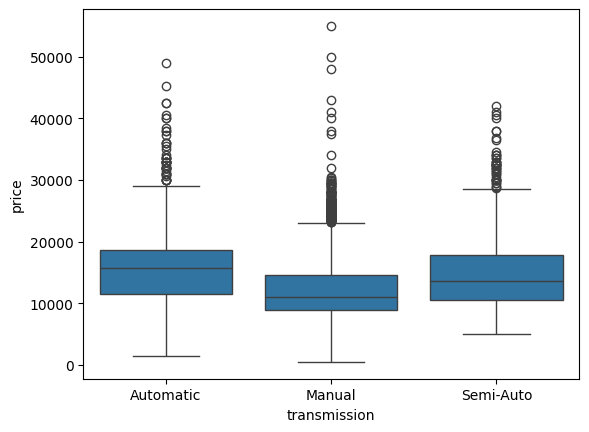

In [15]:
sns.boxplot(data = df, x = 'transmission',y = 'price')

<Axes: xlabel='fuelType', ylabel='price'>

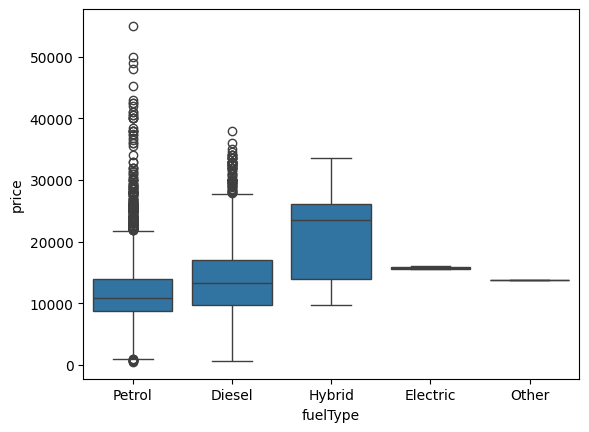

In [16]:
sns.boxplot(data = df,x = 'fuelType', y = 'price' )

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

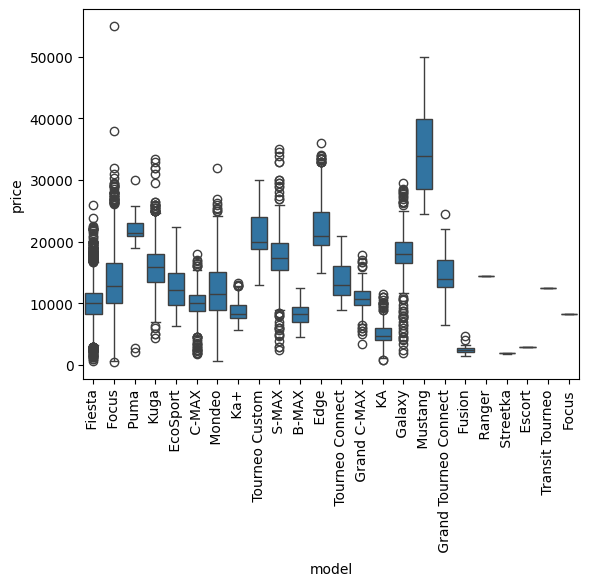

In [17]:
sns.boxplot(x = df['model'],y = df['price'])
plt.xticks(rotation = 90)

In [18]:
X = df.drop(columns = ['price'],axis = 1)
Y = df['price']

In [19]:
df.columns
print(X.columns)

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')


In [20]:
X_one_encode = pd.get_dummies(X,columns = ['model','transmission','fuelType'],drop_first = True)

In [21]:
X_one_encode = X_one_encode.astype(int)
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17960,2017,16700,150,47,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17961,2014,40700,30,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17963,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [22]:
from sklearn.preprocessing import LabelEncoder

columns = ['model', 'transmission', 'fuelType']

Xlable = X.copy()  # make a safe copy
label_encoders = {}

for col in columns:
    le = LabelEncoder()
    Xlable[col] = le.fit_transform(Xlable[col].astype(str))  # Convert to string in case of nulls
    label_encoders[col] = le


In [23]:
Xlable

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17960,0,2017,1,16700,4,150,47.1,1.4
17961,0,2014,1,40700,4,30,57.7,1.0
17962,6,2015,1,7010,0,20,67.3,1.6
17963,11,2018,1,5007,4,145,57.7,1.2


In [24]:
label_encoders

{'model': LabelEncoder(),
 'transmission': LabelEncoder(),
 'fuelType': LabelEncoder()}

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()
X_one_encode[numerical_cols] = scaler.fit_transform(X_one_encode[numerical_cols])

In [27]:
X_one_encode # one Hot encoded 

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067129,-0.380925,0.591460,-0.042209,-0.447999,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.560975,-0.733302,0.591460,-0.042209,-0.447999,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.067129,-0.560067,0.591460,-0.042209,-0.447999,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.054821,-0.662580,0.510826,-1.721346,-0.447999,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.054821,-1.123685,0.510826,-0.931164,-0.447999,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17960,0.067129,-0.342098,0.591460,-1.029937,-0.447999,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17961,-1.414410,0.890528,-1.343753,-0.042209,-0.447999,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-0.920563,-0.839770,-1.505021,0.945519,-0.447999,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17963,0.560975,-0.942643,0.510826,-0.042209,-0.447999,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [28]:
Xlable[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']] = scaler.fit_transform(Xlable[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']])

In [29]:
Xlable  # label Encoded data

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460715,0.067129,-2.670637,-0.380925,0.688805,0.591460,-0.020525,-0.811358
1,-0.211498,0.560975,0.041210,-0.733302,0.688805,0.591460,-0.020525,-0.811358
2,-0.211498,0.067129,0.041210,-0.560067,0.688805,0.591460,-0.020525,-0.811358
3,-0.460715,1.054821,0.041210,-0.662580,0.688805,0.510826,-1.739032,0.345067
4,-0.460715,1.054821,-2.670637,-1.123685,0.688805,0.510826,-0.909408,-0.811358
...,...,...,...,...,...,...,...,...
17960,-1.706799,0.067129,0.041210,-0.342098,0.688805,0.591460,-1.067432,0.113782
17961,-1.706799,-1.414410,0.041210,0.890528,0.688805,-1.343753,-0.020525,-0.811358
17962,-0.211498,-0.920563,0.041210,-0.839770,-1.454039,-1.505021,0.927616,0.576352
17963,1.034586,0.560975,0.041210,-0.942643,0.688805,0.510826,-0.020525,-0.348788


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encode, Y, test_size=0.33, random_state=42)

In [32]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = model.predict(X_test)

In [34]:
y_pred

array([15614.28337909,  9380.04868379,  9422.61901053, ...,
       19287.59693504,  4957.56581554, 10328.76313914])

In [35]:
y_test

17609    12495
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [36]:
r2 = r2_score(y_test,y_pred)
r2

0.8396477408078156

In [37]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R² Score:", adjusted_r2)

Adjusted R² Score: 0.838722736258692


In [38]:
X_train, X_test, y_train, y_test = train_test_split(Xlable, Y, test_size=0.33, random_state=42)
model2 = LinearRegression()
model2.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_pred = model2.predict(X_test)
y_pred

array([15896.45454732,  9330.00316057,  9521.9045313 , ...,
       19789.00302529,  7313.98867854,  9904.92057401])

In [40]:
y_test

17609    12495
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [41]:
r2 = r2_score(y_test,y_pred)
r2

0.7309524107304768